
# Appendix A0: Inner Product Spaces And Self-Adjoint Linear Maps

Source orientation: Pressley, Appendix 0, PDF pages 379-381. The source span introduces bilinear forms, symmetric forms, associated quadratic forms, inner products, orthonormal bases, self-adjoint maps, eigenvectors, and the spectral theorem for real symmetric matrices.

Chapter goal: turn the appendix into a computational toolkit for differential geometry. By the end, an inner product is a metric matrix, an orthonormal basis is a coordinate system that makes the metric look like the identity, a self-adjoint map is the linear algebra behind shape operators, and the spectral theorem is the reason principal curvature directions can be chosen orthogonal.



## Computational Translation Guide

| Book-side idea | Computational object | Inspection target |
| --- | --- | --- |
| Bilinear form | Matrix `B` with value `x.T @ B @ y` | Matrix entries determine all pairings once a basis is chosen. |
| Symmetric bilinear form | Symmetric matrix `B == B.T` | The quadratic form `q(x) = x.T @ B @ x` determines the symmetric pairing by polarization. |
| Inner product | Symmetric positive-definite metric matrix `G` | The unit circle becomes the metric ellipse `x.T @ G @ x = 1`. |
| Orthonormal basis | Matrix `Q` with `Q.T @ G @ Q = I` | Coordinates in this basis measure lengths and angles with the ordinary dot product. |
| Self-adjoint map | Matrix `A` satisfying `A.T @ G == G @ A` | The form `<A x, y>` is symmetric even when `A` is not Euclidean-symmetric in a skewed basis. |
| Spectral theorem | `G`-orthonormal eigenvectors and diagonal matrix | Principal axes and principal curvature directions come from the same eigenframe idea. |



## Route Through The Notebook

1. Build an inner product as a metric matrix and draw the measuring devices it creates.
2. Run Gram-Schmidt with that metric and verify `Q.T @ G @ Q = I`.
3. Recover a symmetric bilinear form from its quadratic form using polarization.
4. Test self-adjointness in a non-orthonormal coordinate system.
5. Diagonalize a self-adjoint map with a `G`-orthonormal eigenbasis.
6. Apply the same calculation to a shape operator, where eigenvectors become principal curvature directions.
7. Finish with an Applied Lab and `final_sanity` checks.


In [1]:

from __future__ import annotations

import json
import math
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp

cwd = Path.cwd()
book_name = "Elementary-Differential-Geometry-Andrew-Pressley"
candidate_roots = [cwd, *cwd.parents]
if (cwd / book_name / "00-book-index.ipynb").exists():
    candidate_roots.insert(0, cwd / book_name)

BOOK_ROOT = None
for candidate in candidate_roots:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate.resolve()
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Pressley book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact
from utils.plotting import PALETTE, require_nonblank_png, set_defaults, style_axis

set_defaults()
UNIT = "appendix-a0"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_DIR = ARTIFACT_ROOT / UNIT
FIGURES = UNIT_ARTIFACT_DIR / "figures"
CHECKS = UNIT_ARTIFACT_DIR / "checks"
TABLES = UNIT_ARTIFACT_DIR / "tables"
for folder in (FIGURES, CHECKS, TABLES):
    folder.mkdir(parents=True, exist_ok=True)

def write_json(path: Path, payload: dict) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, sort_keys=True), encoding="utf-8")
    return path

def save_figure(fig: plt.Figure, filename: str) -> Path:
    path = FIGURES / filename
    fig.savefig(path, dpi=170, bbox_inches="tight")
    plt.close(fig)
    require_nonblank_png(path)
    return path

def metric_inner(x, y, G) -> float:
    return float(np.asarray(x).T @ G @ np.asarray(y))

def metric_norm(x, G) -> float:
    return math.sqrt(max(metric_inner(x, x, G), 0.0))

def normalize_metric(x, G):
    x = np.asarray(x, dtype=float)
    return x / metric_norm(x, G)

def g_gram_schmidt(basis_columns, G):
    vectors = []
    for j in range(basis_columns.shape[1]):
        w = basis_columns[:, j].astype(float).copy()
        for q in vectors:
            w = w - q * metric_inner(q, w, G)
        vectors.append(w / metric_norm(w, G))
    return np.column_stack(vectors)

def ellipse_points_for_metric(M, level=1.0, samples=361):
    theta = np.linspace(0.0, 2.0 * np.pi, samples)
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    eigvals, eigvecs = np.linalg.eigh(M)
    transform = eigvecs @ np.diag(np.sqrt(level / eigvals))
    return (transform @ circle).T

def draw_vector(ax, vector, label, color, scale=1.0, linestyle="-"):
    v = np.asarray(vector, dtype=float) * scale
    ax.annotate("", xy=(v[0], v[1]), xytext=(0, 0), arrowprops={"arrowstyle": "-|>", "lw": 2.2, "color": color, "linestyle": linestyle})
    ax.text(v[0] * 1.08, v[1] * 1.08, label, color=color, fontsize=10, ha="center", va="center")



## Source Span Metadata

The PDF pages name the basic objects and state the finite-dimensional spectral facts. The notebook uses that span only for orientation; the prose, examples, diagrams, checks, and lab below are original teaching material.


In [2]:

source_span = {
    "unit": UNIT,
    "title": "Inner product spaces and self-adjoint linear maps",
    "source": "Pressley, Elementary Differential Geometry, Appendix 0",
    "pdf_pages": "379-381",
    "printed_span": "Appendix 0",
    "source_use": "orientation only; no copied textbook prose, figures, exercises, hints, or solutions",
    "concepts": ["bilinear forms", "symmetric bilinear forms", "quadratic forms and polarization", "inner products and orthonormal bases", "self-adjoint linear maps", "eigenvectors and spectral theorem", "matrix diagonalization for symmetric matrices"],
}
source_span_path = write_json(CHECKS / "source-span.json", source_span)
source_span


{'unit': 'appendix-a0',
 'title': 'Inner product spaces and self-adjoint linear maps',
 'source': 'Pressley, Elementary Differential Geometry, Appendix 0',
 'pdf_pages': '379-381',
 'printed_span': 'Appendix 0',
 'source_use': 'orientation only; no copied textbook prose, figures, exercises, hints, or solutions',
 'concepts': ['bilinear forms',
  'symmetric bilinear forms',
  'quadratic forms and polarization',
  'inner products and orthonormal bases',
  'self-adjoint linear maps',
  'eigenvectors and spectral theorem',
  'matrix diagonalization for symmetric matrices']}


## 1. Inner Products As Measuring Devices

Once a basis is chosen, an inner product is a symmetric positive-definite matrix `G`. The formula `<x,y>_G = x.T @ G @ y` changes lengths, angles, and perpendicularity. The first figure draws the metric unit circle and a pair of vectors that are perpendicular for `G`; they need not look perpendicular to the Euclidean eye.


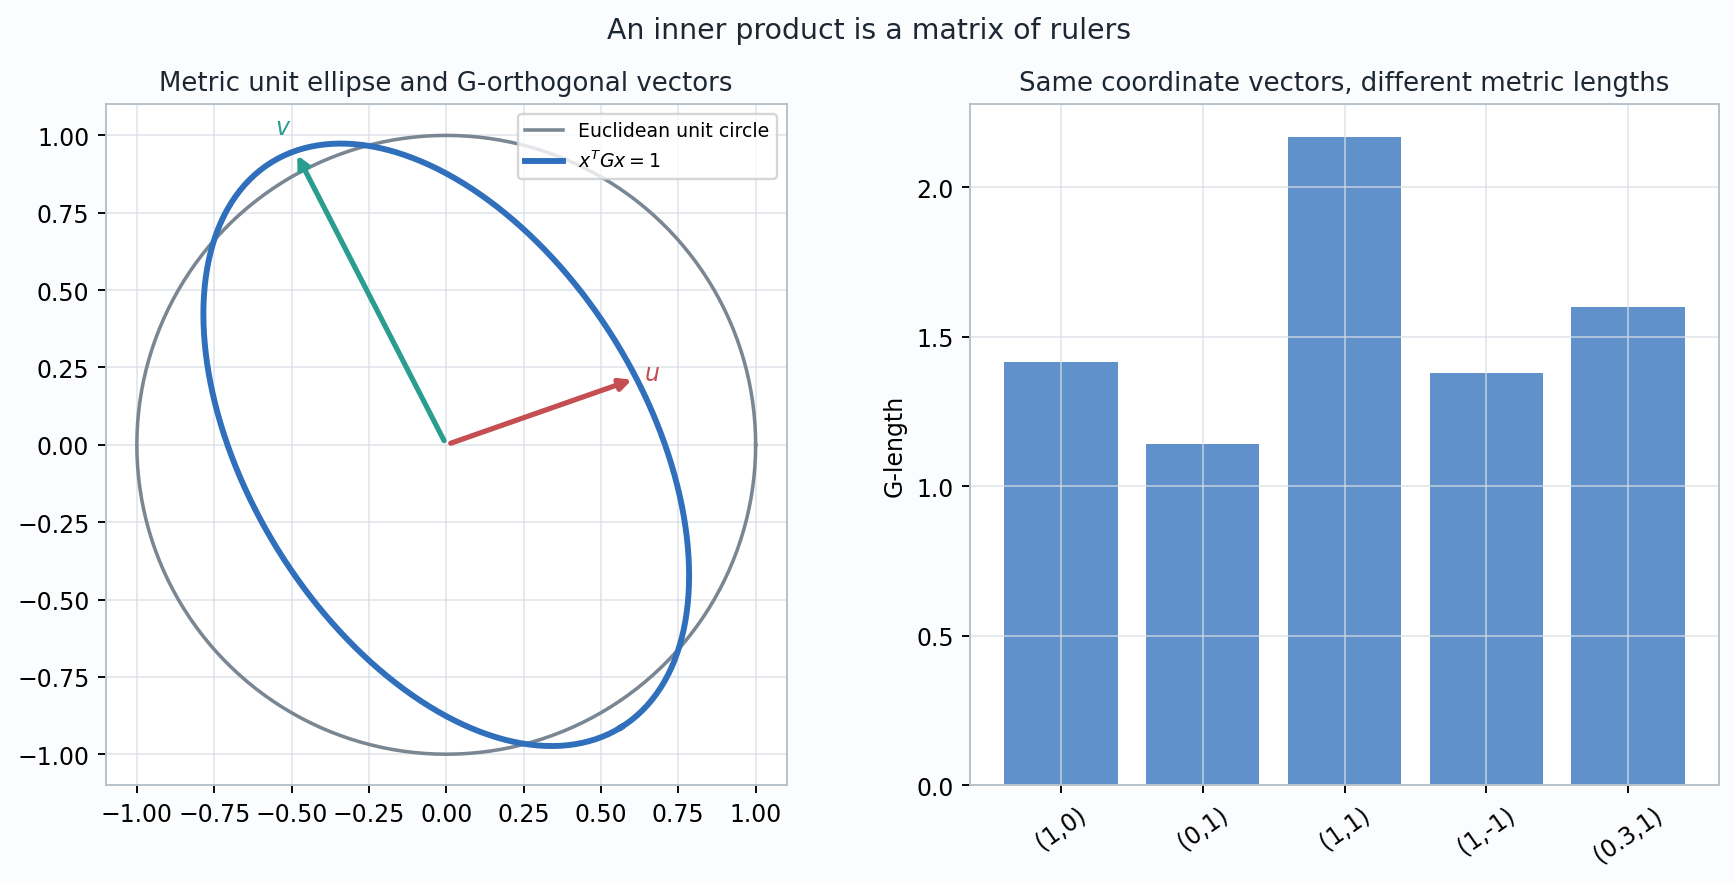

{'metric_matrix': [[2.0, 0.7], [0.7, 1.3]],
 'symmetric_residual': 0.0,
 'min_eigenvalue': 0.8673762078750737,
 'u_G_norm': 0.9999999999999999,
 'v_G_norm': 0.9999999999999999,
 'G_orthogonality_residual': 0.0,
 'max_cauchy_schwarz_excess': -0.003942905774415584,
 'artifact': 'artifacts/appendix-a0/figures/inner-product-metric-rulers.png'}

In [3]:

G = np.array([[2.0, 0.70], [0.70, 1.30]], dtype=float)
G_eigvals = np.linalg.eigvalsh(G)

u = normalize_metric(np.array([1.0, 0.35]), G)
Gu = G @ u
v = normalize_metric(np.array([-Gu[1], Gu[0]]), G)
metric_ellipse = ellipse_points_for_metric(G)
theta = np.linspace(0, 2 * np.pi, 361)
euclidean_circle = np.column_stack([np.cos(theta), np.sin(theta)])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
axes[0].plot(euclidean_circle[:, 0], euclidean_circle[:, 1], color=PALETTE["gray"], lw=1.5, label="Euclidean unit circle")
axes[0].plot(metric_ellipse[:, 0], metric_ellipse[:, 1], color=PALETTE["blue"], lw=2.5, label="$x^T G x = 1$")
draw_vector(axes[0], u, "$u$", PALETTE["red"])
draw_vector(axes[0], v, "$v$", PALETTE["teal"])
axes[0].legend(loc="upper right", fontsize=8)
style_axis(axes[0], "Metric unit ellipse and G-orthogonal vectors", equal=True)

sample_points = np.array([[1, 0], [0, 1], [1, 1], [1, -1], [0.3, 1.2]], dtype=float)
for point in sample_points:
    axes[1].bar(f"({point[0]:.1g},{point[1]:.1g})", metric_norm(point, G), color=PALETTE["blue"], alpha=0.76)
axes[1].set_ylabel("G-length")
axes[1].tick_params(axis="x", rotation=35)
style_axis(axes[1], "Same coordinate vectors, different metric lengths", grid=True)
fig.suptitle("An inner product is a matrix of rulers", color=PALETTE["ink"])
inner_product_fig_path = save_figure(fig, "inner-product-metric-rulers.png")

g_rng = np.random.default_rng(20260512)
cs_excess = []
for a, b in zip(g_rng.normal(size=(32, 2)), g_rng.normal(size=(32, 2))):
    cs_excess.append(abs(metric_inner(a, b, G)) - metric_norm(a, G) * metric_norm(b, G))
inner_product_checks = {
    "metric_matrix": G.tolist(),
    "symmetric_residual": float(np.linalg.norm(G - G.T)),
    "min_eigenvalue": float(np.min(G_eigvals)),
    "u_G_norm": metric_norm(u, G),
    "v_G_norm": metric_norm(v, G),
    "G_orthogonality_residual": abs(metric_inner(u, v, G)),
    "max_cauchy_schwarz_excess": float(max(cs_excess)),
    "artifact": inner_product_fig_path.relative_to(BOOK_ROOT).as_posix(),
}
inner_product_checks_path = write_json(CHECKS / "inner-product-checks.json", inner_product_checks)
display_artifact(inner_product_fig_path, width=900)
inner_product_checks



## 2. Orthonormal Bases Are Coordinates That Hide The Metric

An orthonormal basis for `<,>_G` is not usually orthonormal for the page's ordinary coordinates. Gram-Schmidt builds columns `Q` whose pairings satisfy `Q.T @ G @ Q = I`. In that basis, all metric computations look like ordinary dot products.


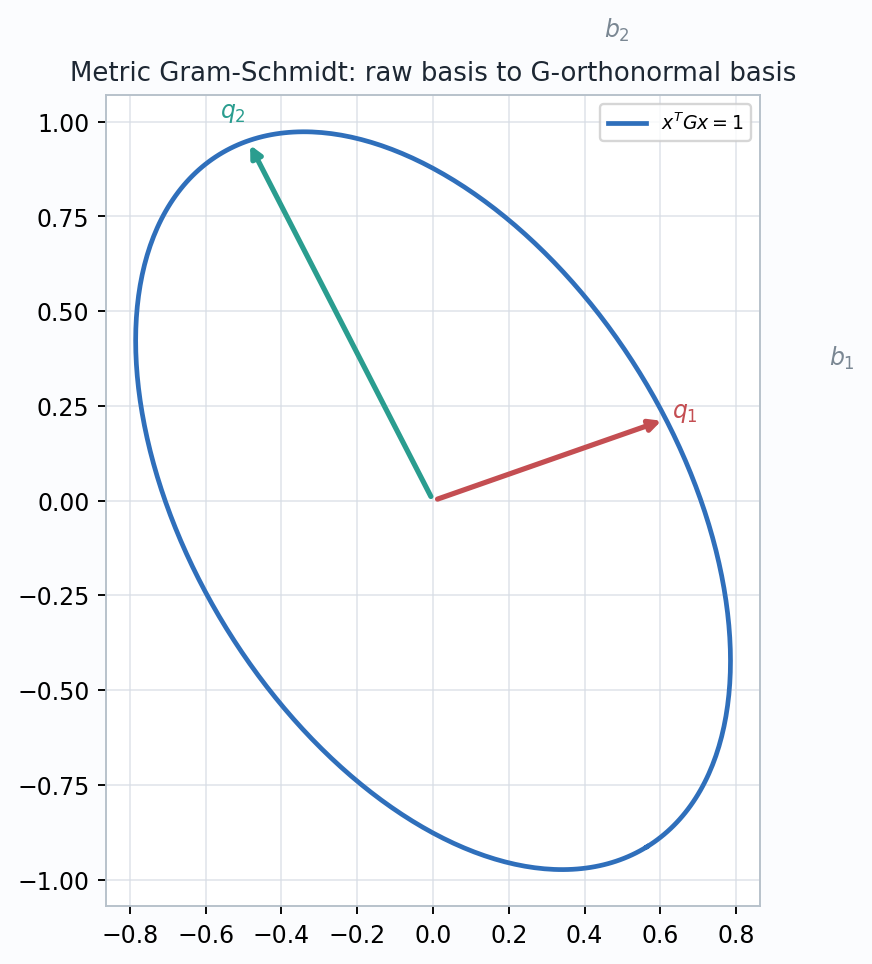

{'raw_basis_columns': [[1.0, 0.45], [0.35, 1.15]],
 'orthonormal_basis_columns': [[0.6143820638443888, -0.48851655417410217],
  [0.21503372234553608, 0.9495408347366753]],
 'Q_transpose_G_Q': [[0.9999999999999998, 3.4829585666260375e-16],
  [3.82387557033261e-16, 1.0000000000000002]],
 'orthonormality_residual': 6.050932661126125e-16,
 'basis_determinant': 0.6884283908215141,
 'artifact': 'artifacts/appendix-a0/figures/gram-schmidt-orthonormal-basis.png'}

In [4]:

raw_basis = np.array([[1.0, 0.45], [0.35, 1.15]], dtype=float)
Q = g_gram_schmidt(raw_basis, G)
G_gram = Q.T @ G @ Q

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.plot(metric_ellipse[:, 0], metric_ellipse[:, 1], color=PALETTE["blue"], lw=2.0, label="$x^T G x = 1$")
for j in range(2):
    draw_vector(ax, raw_basis[:, j], f"$b_{j+1}$", PALETTE["gray"], linestyle="--")
for j, color in enumerate([PALETTE["red"], PALETTE["teal"]]):
    draw_vector(ax, Q[:, j], f"$q_{j+1}$", color)
ax.legend(loc="upper right", fontsize=8)
style_axis(ax, "Metric Gram-Schmidt: raw basis to G-orthonormal basis", equal=True)
gram_schmidt_fig_path = save_figure(fig, "gram-schmidt-orthonormal-basis.png")

gram_schmidt_checks = {
    "raw_basis_columns": raw_basis.tolist(),
    "orthonormal_basis_columns": Q.tolist(),
    "Q_transpose_G_Q": G_gram.tolist(),
    "orthonormality_residual": float(np.linalg.norm(G_gram - np.eye(2))),
    "basis_determinant": float(np.linalg.det(Q)),
    "artifact": gram_schmidt_fig_path.relative_to(BOOK_ROOT).as_posix(),
}
gram_schmidt_checks_path = write_json(CHECKS / "gram-schmidt-checks.json", gram_schmidt_checks)
display_artifact(gram_schmidt_fig_path, width=760)
gram_schmidt_checks



## 3. Bilinear And Quadratic Forms

A symmetric bilinear form and its quadratic form carry the same information. Computationally, polarization recovers the mixed pairing from three quadratic evaluations. A non-symmetric bilinear form does not survive this compression: its skew part vanishes in `x.T @ B @ x`.


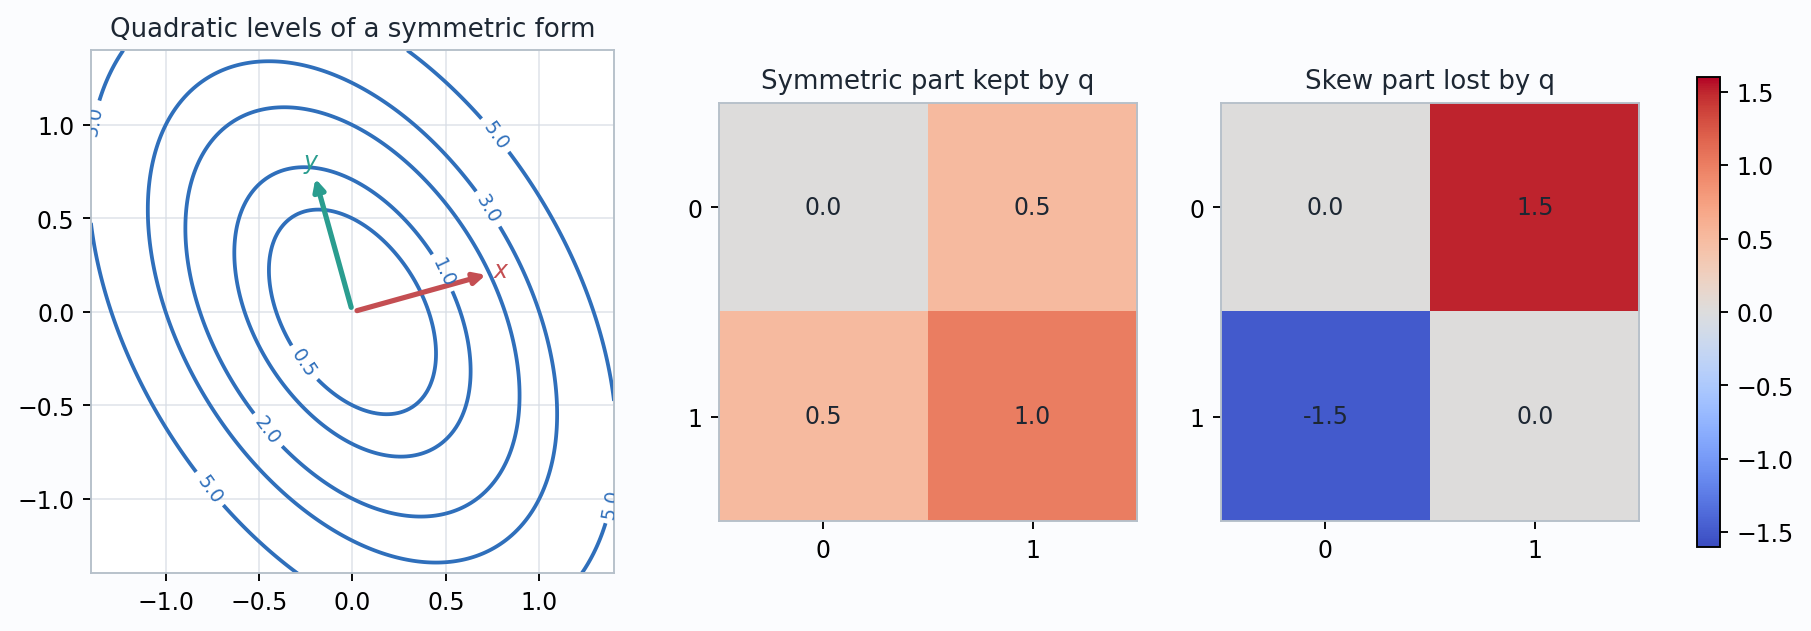

{'symmetric_matrix_B': [[3, 1], [1, 2]],
 'quadratic_form': 'x1*(3*x1 + x2) + x2*(x1 + 2*x2)',
 'polarization_residual': '0',
 'non_symmetric_C': [[0, 2], [-1, 1]],
 'skew_part_quadratic_residual': '0',
 'min_eigenvalue_B': 1.381966011250105,
 'artifact': 'artifacts/appendix-a0/figures/bilinear-quadratic-polarization.png'}

In [5]:

x1, x2, y1, y2 = sp.symbols("x1 x2 y1 y2", real=True)
x_sym = sp.Matrix([x1, x2])
y_sym = sp.Matrix([y1, y2])
B_sym = sp.Matrix([[3, 1], [1, 2]])
q_sym = (x_sym.T * B_sym * x_sym)[0]
polarization_residual = sp.simplify(sp.Rational(1, 2) * (((x_sym + y_sym).T * B_sym * (x_sym + y_sym))[0] - (x_sym.T * B_sym * x_sym)[0] - (y_sym.T * B_sym * y_sym)[0]) - (x_sym.T * B_sym * y_sym)[0])
C_sym = sp.Matrix([[0, 2], [-1, 1]])
C_symmetric_part = sp.Rational(1, 2) * (C_sym + C_sym.T)
C_skew_part = sp.Rational(1, 2) * (C_sym - C_sym.T)
skew_disappears = sp.simplify((x_sym.T * C_sym * x_sym)[0] - (x_sym.T * C_symmetric_part * x_sym)[0])

B_numeric = np.array(B_sym.tolist(), dtype=float)
S_numeric = np.array(C_symmetric_part.tolist(), dtype=float)
K_numeric = np.array(C_skew_part.tolist(), dtype=float)
xs = np.linspace(-1.4, 1.4, 180)
ys = np.linspace(-1.4, 1.4, 180)
X, Y = np.meshgrid(xs, ys)
Z = B_numeric[0, 0] * X**2 + 2 * B_numeric[0, 1] * X * Y + B_numeric[1, 1] * Y**2

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
contours = axes[0].contour(X, Y, Z, levels=[0.5, 1.0, 2.0, 3.0, 5.0], colors=[PALETTE["blue"]], linewidths=1.6)
axes[0].clabel(contours, inline=True, fontsize=8)
draw_vector(axes[0], [0.9, 0.25], "$x$", PALETTE["red"], scale=0.82)
draw_vector(axes[0], [-0.25, 0.9], "$y$", PALETTE["teal"], scale=0.82)
style_axis(axes[0], "Quadratic levels of a symmetric form", equal=True)
for ax, matrix, title in [(axes[1], S_numeric, "Symmetric part kept by q"), (axes[2], K_numeric, "Skew part lost by q")]:
    image = ax.imshow(matrix, cmap="coolwarm", vmin=-1.6, vmax=1.6)
    for (i, j), value in np.ndenumerate(matrix):
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", color=PALETTE["ink"], fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    style_axis(ax, title, grid=False)
fig.colorbar(image, ax=axes[1:].ravel().tolist(), shrink=0.78)
bilinear_fig_path = save_figure(fig, "bilinear-quadratic-polarization.png")

bilinear_checks = {
    "symmetric_matrix_B": [[int(v) for v in row] for row in B_sym.tolist()],
    "quadratic_form": str(q_sym),
    "polarization_residual": str(polarization_residual),
    "non_symmetric_C": [[int(v) for v in row] for row in C_sym.tolist()],
    "skew_part_quadratic_residual": str(skew_disappears),
    "min_eigenvalue_B": float(np.min(np.linalg.eigvalsh(B_numeric))),
    "artifact": bilinear_fig_path.relative_to(BOOK_ROOT).as_posix(),
}
bilinear_checks_path = write_json(CHECKS / "bilinear-quadratic-checks.json", bilinear_checks)
display_artifact(bilinear_fig_path, width=920)
bilinear_checks



## 4. Self-Adjointness Depends On The Inner Product

In a `G`-metric, the matrix test for a self-adjoint map is `A.T @ G = G @ A`. This explains why a shape operator can fail to look symmetric in arbitrary coordinates while still being geometrically self-adjoint. Once we move to a `G`-orthonormal basis, its matrix becomes symmetric.


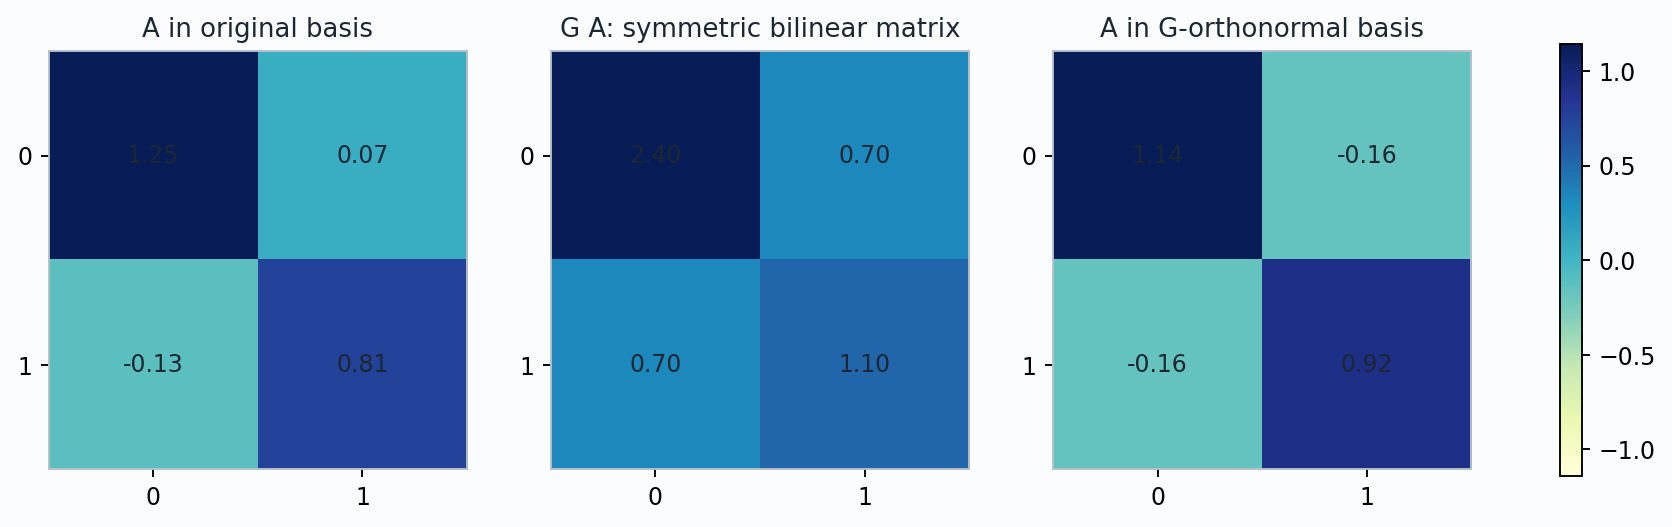

{'A_matrix_original_basis': [[1.2464454976303316, 0.0663507109004739],
  [-0.13270142180094788, 0.8104265402843602]],
 'G_A_matrix': [[2.4, 0.7], [0.6999999999999998, 1.1]],
 'A_matrix_G_orthonormal_basis': [[1.1417382278003207, -0.1608909835527565],
  [-0.1608909835527566, 0.915133810114371]],
 'euclidean_symmetry_residual_original_basis': 0.28150222568563976,
 'self_adjoint_residual': 1.5700924586837752e-16,
 'pairing_residual_sample': 0.0,
 'orthonormal_basis_symmetry_residual': 1.5700924586837752e-16,
 'artifact': 'artifacts/appendix-a0/figures/self-adjoint-coordinate-test.png'}

In [6]:

H = np.array([[2.40, 0.70], [0.70, 1.10]], dtype=float)
A = np.linalg.solve(G, H)
adjoint_residual_matrix = A.T @ G - G @ A
A_in_Q = np.linalg.solve(Q, A @ Q)

x_test = np.array([0.7, -0.4])
y_test = np.array([0.2, 1.1])
pairing_residual = metric_inner(A @ x_test, y_test, G) - metric_inner(x_test, A @ y_test, G)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax, matrix, title in zip(axes, [A, G @ A, A_in_Q], ["A in original basis", "G A: symmetric bilinear matrix", "A in G-orthonormal basis"]):
    vmax = max(1.0, float(np.max(np.abs(matrix))))
    image = ax.imshow(matrix, cmap="YlGnBu", vmin=-vmax, vmax=vmax)
    for (i, j), value in np.ndenumerate(matrix):
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=PALETTE["ink"], fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    style_axis(ax, title, grid=False)
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75)
self_adjoint_fig_path = save_figure(fig, "self-adjoint-coordinate-test.png")

self_adjoint_checks = {
    "A_matrix_original_basis": A.tolist(),
    "G_A_matrix": (G @ A).tolist(),
    "A_matrix_G_orthonormal_basis": A_in_Q.tolist(),
    "euclidean_symmetry_residual_original_basis": float(np.linalg.norm(A - A.T)),
    "self_adjoint_residual": float(np.linalg.norm(adjoint_residual_matrix)),
    "pairing_residual_sample": float(abs(pairing_residual)),
    "orthonormal_basis_symmetry_residual": float(np.linalg.norm(A_in_Q - A_in_Q.T)),
    "artifact": self_adjoint_fig_path.relative_to(BOOK_ROOT).as_posix(),
}
self_adjoint_checks_path = write_json(CHECKS / "self-adjoint-checks.json", self_adjoint_checks)
display_artifact(self_adjoint_fig_path, width=920)
self_adjoint_checks



## 5. Spectral Theorem In A Metric Basis

The spectral theorem says a self-adjoint map has an orthonormal eigenbasis. With a non-identity metric matrix, the eigenvectors can be scaled so that `E.T @ G @ E = I`, and the coordinate matrix `E^{-1} A E` is diagonal. The Rayleigh quotient `<A x, x>_G / <x, x>_G` reaches its extrema along those eigenvectors.


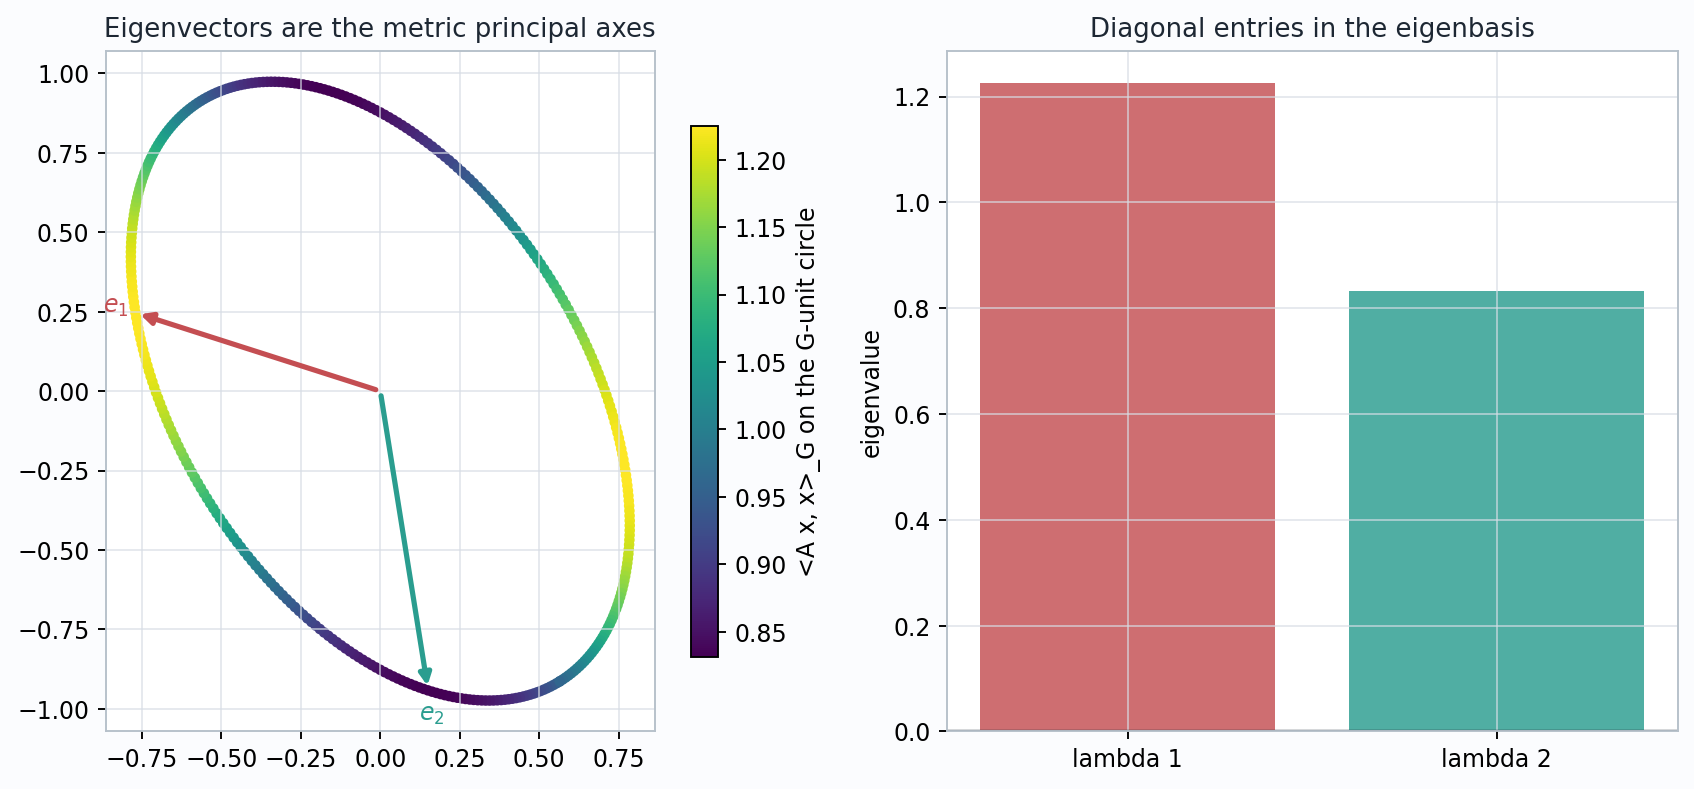

{'eigenvalues_descending': [1.2252183838106794, 0.8316536541040124],
 'E_transpose_G_E': [[0.9999999999999997, 1.8730479649533254e-16],
  [2.295639983105114e-16, 1.0000000000000002]],
 'diagonalized_matrix': [[1.2252183838106796, 3.603058363180463e-17],
  [-6.211555976459811e-17, 0.8316536541040124]],
 'G_orthonormal_eigenbasis_residual': 4.980161518299226e-16,
 'diagonalization_residual': 2.333674191013627e-16,
 'eigen_equation_residual': 1.594436429147036e-16,
 'rayleigh_min': 0.8316544339632972,
 'rayleigh_max': 1.2252176039513947,
 'artifact': 'artifacts/appendix-a0/figures/spectral-theorem-eigenframe.png'}

In [7]:

A_in_Q_symmetric = 0.5 * (A_in_Q + A_in_Q.T)
eigenvalues, U = np.linalg.eigh(A_in_Q_symmetric)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
U = U[:, order]
E = Q @ U
E_metric_gram = E.T @ G @ E
D = np.linalg.solve(E, A @ E)
unit_points = ellipse_points_for_metric(G, samples=361)
rayleigh = np.array([metric_inner(A @ p, p, G) / metric_inner(p, p, G) for p in unit_points])

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2))
scatter = axes[0].scatter(unit_points[:, 0], unit_points[:, 1], c=rayleigh, cmap="viridis", s=12)
for j, color in enumerate([PALETTE["red"], PALETTE["teal"]]):
    draw_vector(axes[0], E[:, j], f"$e_{j+1}$", color)
style_axis(axes[0], "Eigenvectors are the metric principal axes", equal=True)
fig.colorbar(scatter, ax=axes[0], shrink=0.78, label="<A x, x>_G on the G-unit circle")
axes[1].bar(["lambda 1", "lambda 2"], eigenvalues, color=[PALETTE["red"], PALETTE["teal"]], alpha=0.82)
axes[1].axhline(0, color=PALETTE["ink"], lw=1)
axes[1].set_ylabel("eigenvalue")
style_axis(axes[1], "Diagonal entries in the eigenbasis", grid=True)
spectral_fig_path = save_figure(fig, "spectral-theorem-eigenframe.png")

spectral_checks = {
    "eigenvalues_descending": eigenvalues.tolist(),
    "E_transpose_G_E": E_metric_gram.tolist(),
    "diagonalized_matrix": D.tolist(),
    "G_orthonormal_eigenbasis_residual": float(np.linalg.norm(E_metric_gram - np.eye(2))),
    "diagonalization_residual": float(np.linalg.norm(D - np.diag(eigenvalues))),
    "eigen_equation_residual": float(np.linalg.norm(A @ E - E @ np.diag(eigenvalues))),
    "rayleigh_min": float(np.min(rayleigh)),
    "rayleigh_max": float(np.max(rayleigh)),
    "artifact": spectral_fig_path.relative_to(BOOK_ROOT).as_posix(),
}
spectral_checks_path = write_json(CHECKS / "spectral-theorem-checks.json", spectral_checks)
display_artifact(spectral_fig_path, width=900)
spectral_checks



## 6. Shape Operators And Principal Curvature Directions

On a surface, the first fundamental form is the inner product on each tangent plane. The second fundamental form is a symmetric bilinear form. The shape operator `W` is defined by `II(v,w) = I(Wv,w)`, so its coordinate matrix satisfies `W.T @ I = I @ W`. Appendix A0 is exactly the linear algebra that makes principal curvature directions available.


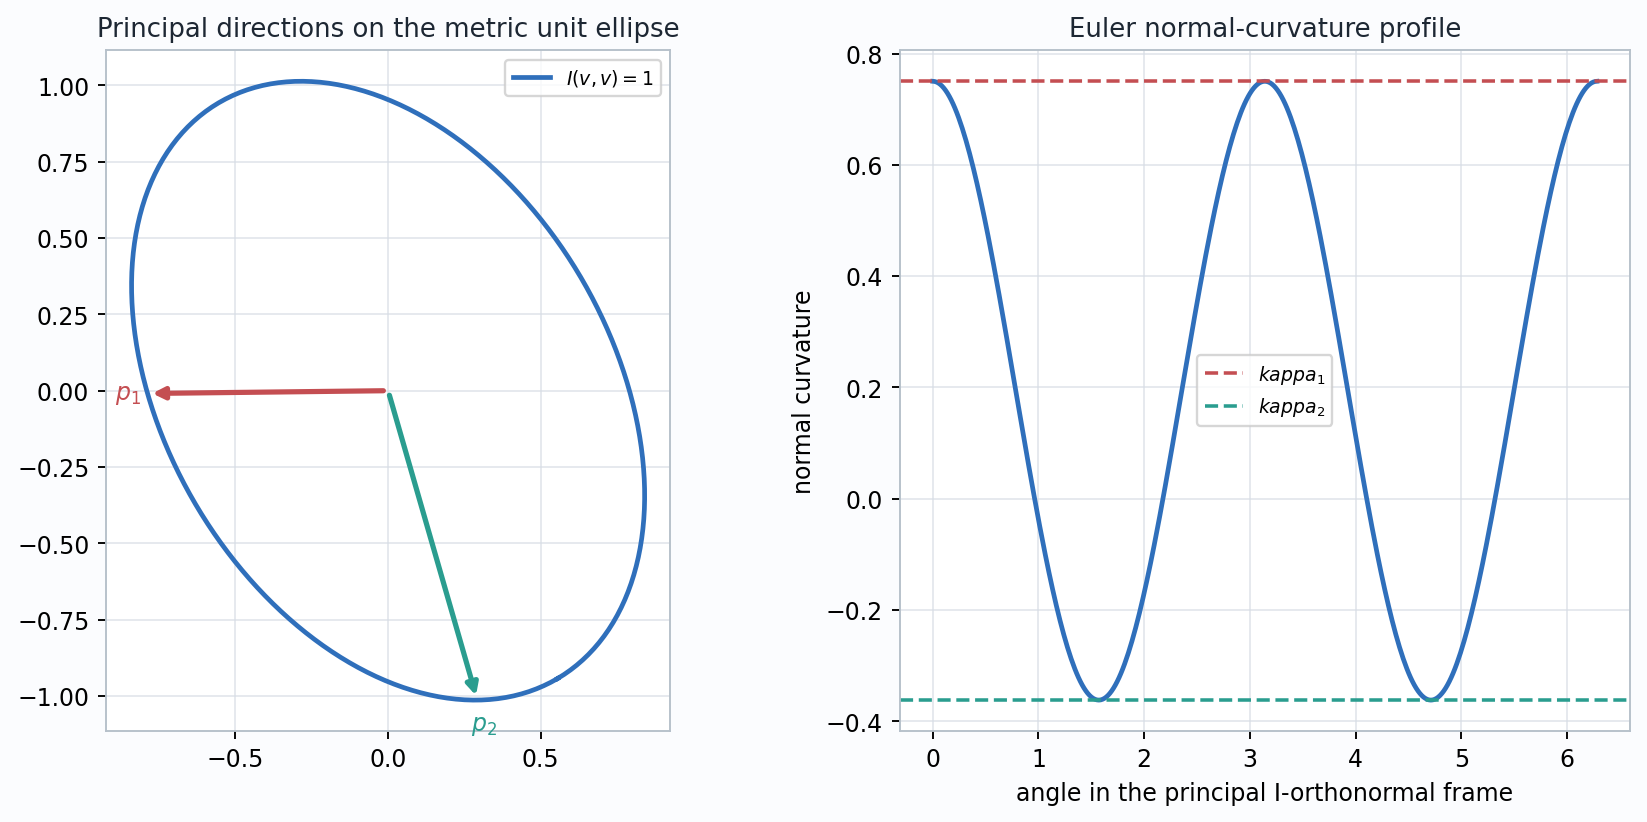

{'first_fundamental_form_I': [[1.6, 0.45], [0.45, 1.1]],
 'second_fundamental_form_II': [[1.2, 0.35], [0.35, -0.25]],
 'shape_operator_W': [[0.7463884430176565, 0.319422150882825],
  [0.012841091492776896, -0.3579454253611557]],
 'self_adjoint_residual': 7.850462293418876e-17,
 'principal_curvatures': [0.7500902453807154, -0.36164722772421476],
 'principal_direction_metric_gram': [[1.0000000000000002,
   3.719172082794904e-17],
  [9.128272771331445e-17, 1.0]],
 'principal_orthonormal_residual': 2.4293943083254404e-16,
 'normal_curvature_max_residual': 1.1102230246251565e-16,
 'normal_curvature_min_residual': 1.1102230246251565e-16,
 'artifact': 'artifacts/appendix-a0/figures/shape-operator-principal-curvature-directions.png'}

In [8]:

I_metric = np.array([[1.60, 0.45], [0.45, 1.10]], dtype=float)
II_form = np.array([[1.20, 0.35], [0.35, -0.25]], dtype=float)
W = np.linalg.solve(I_metric, II_form)
Q_surface = g_gram_schmidt(np.eye(2), I_metric)
W_in_Q_surface = np.linalg.solve(Q_surface, W @ Q_surface)
W_in_Q_surface = 0.5 * (W_in_Q_surface + W_in_Q_surface.T)
kappa, U_surface = np.linalg.eigh(W_in_Q_surface)
shape_order = np.argsort(kappa)[::-1]
kappa = kappa[shape_order]
U_surface = U_surface[:, shape_order]
principal_dirs = Q_surface @ U_surface
principal_gram = principal_dirs.T @ I_metric @ principal_dirs

angle = np.linspace(0, 2 * np.pi, 361)
direction_samples = np.outer(np.cos(angle), principal_dirs[:, 0]) + np.outer(np.sin(angle), principal_dirs[:, 1])
normal_curvatures = np.array([(d.T @ II_form @ d) / (d.T @ I_metric @ d) for d in direction_samples])
I_unit = ellipse_points_for_metric(I_metric)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2))
axes[0].plot(I_unit[:, 0], I_unit[:, 1], color=PALETTE["blue"], lw=2.0, label="$I(v,v)=1$")
for j, color in enumerate([PALETTE["red"], PALETTE["teal"]]):
    draw_vector(axes[0], principal_dirs[:, j], f"$p_{j+1}$", color)
axes[0].legend(loc="upper right", fontsize=8)
style_axis(axes[0], "Principal directions on the metric unit ellipse", equal=True)
axes[1].plot(angle, normal_curvatures, color=PALETTE["blue"], lw=2.0)
axes[1].axhline(kappa[0], color=PALETTE["red"], linestyle="--", label="$kappa_1$")
axes[1].axhline(kappa[1], color=PALETTE["teal"], linestyle="--", label="$kappa_2$")
axes[1].set_xlabel("angle in the principal I-orthonormal frame")
axes[1].set_ylabel("normal curvature")
axes[1].legend(fontsize=8)
style_axis(axes[1], "Euler normal-curvature profile", grid=True)
shape_operator_fig_path = save_figure(fig, "shape-operator-principal-curvature-directions.png")

principal_checks = {
    "first_fundamental_form_I": I_metric.tolist(),
    "second_fundamental_form_II": II_form.tolist(),
    "shape_operator_W": W.tolist(),
    "self_adjoint_residual": float(np.linalg.norm(W.T @ I_metric - I_metric @ W)),
    "principal_curvatures": kappa.tolist(),
    "principal_direction_metric_gram": principal_gram.tolist(),
    "principal_orthonormal_residual": float(np.linalg.norm(principal_gram - np.eye(2))),
    "normal_curvature_max_residual": float(abs(np.max(normal_curvatures) - kappa[0])),
    "normal_curvature_min_residual": float(abs(np.min(normal_curvatures) - kappa[1])),
    "artifact": shape_operator_fig_path.relative_to(BOOK_ROOT).as_posix(),
}
principal_checks_path = write_json(CHECKS / "principal-curvature-link-checks.json", principal_checks)
display_artifact(shape_operator_fig_path, width=900)
principal_checks



## Proof-State Scaffold

The appendix is short, but it carries a long dependency chain used throughout the surface chapters. This graph shows the route from pairings to principal directions. The check attached to the graph verifies that the dependencies are acyclic and that the route from inner product to principal curvature directions is present.


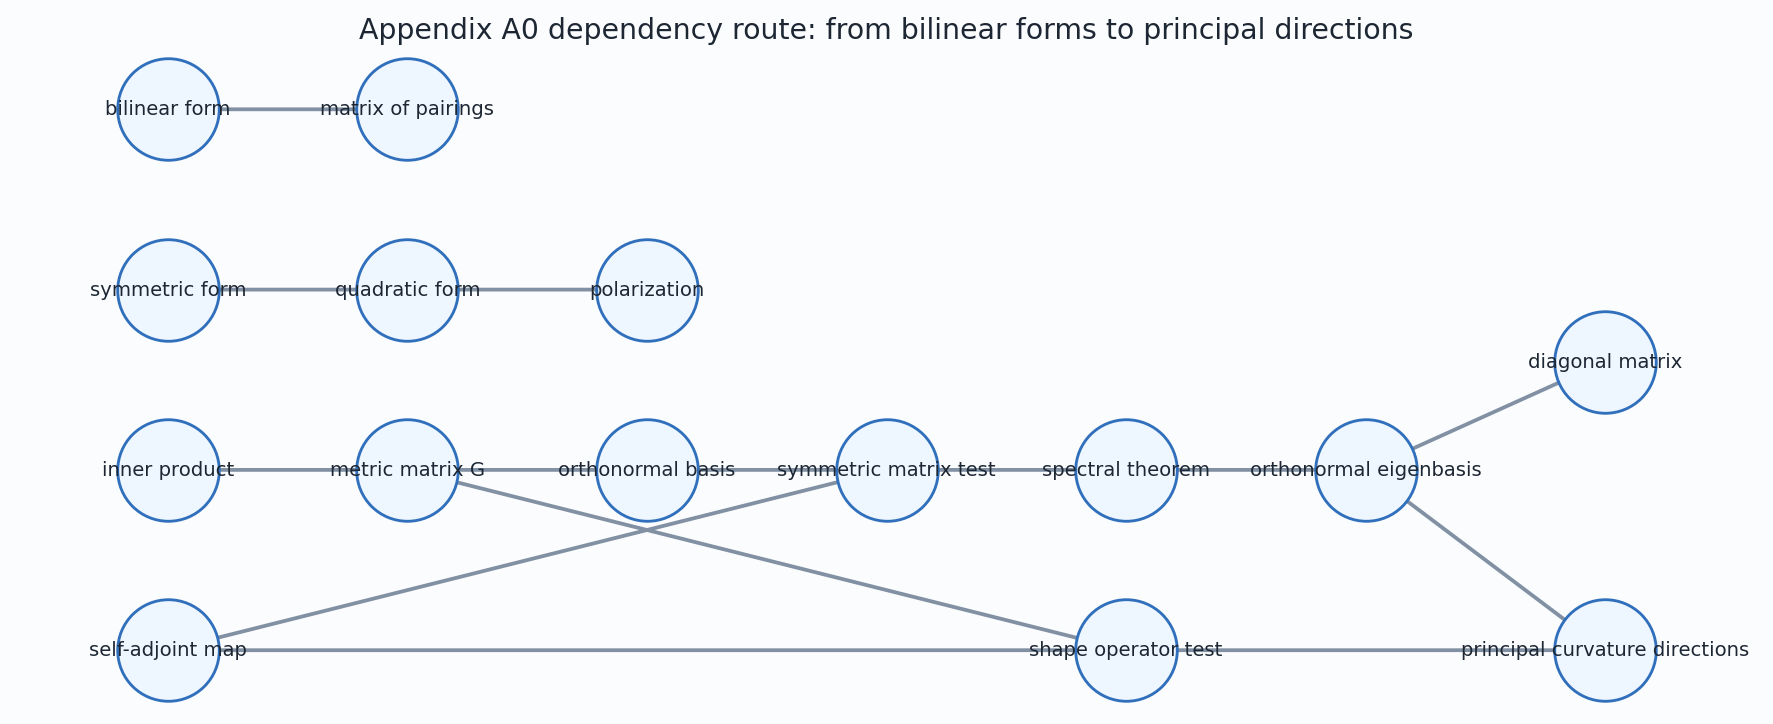

{'node_count': 15,
 'edge_count': 14,
 'is_directed_acyclic_graph': True,
 'has_inner_product_to_principal_direction_route': True,
 'artifact': 'artifacts/appendix-a0/figures/proof-route-spectral-theorem.png'}

In [9]:

route_graph = nx.DiGraph()
route_edges = [
    ("bilinear form", "matrix of pairings"), ("symmetric form", "quadratic form"), ("quadratic form", "polarization"),
    ("inner product", "metric matrix G"), ("metric matrix G", "orthonormal basis"),
    ("orthonormal basis", "symmetric matrix test"), ("self-adjoint map", "symmetric matrix test"),
    ("symmetric matrix test", "spectral theorem"), ("spectral theorem", "orthonormal eigenbasis"),
    ("orthonormal eigenbasis", "diagonal matrix"), ("metric matrix G", "shape operator test"),
    ("self-adjoint map", "shape operator test"), ("shape operator test", "principal curvature directions"),
    ("orthonormal eigenbasis", "principal curvature directions"),
]
route_graph.add_edges_from(route_edges)
route_pos = {
    "bilinear form": (0, 3), "matrix of pairings": (1.4, 3), "symmetric form": (0, 2),
    "quadratic form": (1.4, 2), "polarization": (2.8, 2), "inner product": (0, 1),
    "metric matrix G": (1.4, 1), "orthonormal basis": (2.8, 1), "self-adjoint map": (0, 0),
    "symmetric matrix test": (4.2, 1), "spectral theorem": (5.6, 1),
    "orthonormal eigenbasis": (7.0, 1), "diagonal matrix": (8.4, 1.6),
    "shape operator test": (5.6, 0), "principal curvature directions": (8.4, 0),
}
fig, ax = plt.subplots(figsize=(13.2, 5.0))
nx.draw_networkx_edges(route_graph, route_pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, edge_color="#8290a3", width=1.6)
nx.draw_networkx_nodes(route_graph, route_pos, ax=ax, node_color="#eef6ff", edgecolors=PALETTE["blue"], node_size=1850, linewidths=1.2)
nx.draw_networkx_labels(route_graph, route_pos, ax=ax, font_size=8.3, font_color=PALETTE["ink"])
ax.set_axis_off()
ax.set_title("Appendix A0 dependency route: from bilinear forms to principal directions", color=PALETTE["ink"])
proof_route_fig_path = save_figure(fig, "proof-route-spectral-theorem.png")
route_checks = {
    "node_count": route_graph.number_of_nodes(),
    "edge_count": route_graph.number_of_edges(),
    "is_directed_acyclic_graph": bool(nx.is_directed_acyclic_graph(route_graph)),
    "has_inner_product_to_principal_direction_route": bool(nx.has_path(route_graph, "inner product", "principal curvature directions")),
    "artifact": proof_route_fig_path.relative_to(BOOK_ROOT).as_posix(),
}
proof_route_checks_path = write_json(CHECKS / "proof-route-checks.json", route_checks)
display_artifact(proof_route_fig_path, width=920)
route_checks



## Applied Lab: Diagnose Principal Directions From Metric Data

The lab uses the same pattern that appears in surface computations: choose a first fundamental form `I`, choose a symmetric second fundamental form `II`, form `W = I^{-1} II`, and inspect whether the resulting shape operator is self-adjoint for `I`. The Euclidean symmetry residual can be large in skewed coordinates; the metric self-adjoint residual should stay near zero.


In [10]:

def shape_operator_diagnostics(case_name, I_form, II_form_case):
    W_case = np.linalg.solve(I_form, II_form_case)
    Q_case = g_gram_schmidt(np.eye(2), I_form)
    W_case_Q = np.linalg.solve(Q_case, W_case @ Q_case)
    W_case_Q = 0.5 * (W_case_Q + W_case_Q.T)
    vals = np.sort(np.linalg.eigvalsh(W_case_Q))[::-1]
    theta_case = np.linspace(0, 2 * np.pi, 721)
    directions_case = np.outer(np.cos(theta_case), Q_case[:, 0]) + np.outer(np.sin(theta_case), Q_case[:, 1])
    normal_profile = np.array([(d.T @ II_form_case @ d) / (d.T @ I_form @ d) for d in directions_case])
    return {
        "case": case_name,
        "metric_offdiag": float(I_form[0, 1]),
        "shape_operator_euclidean_symmetry_residual": float(np.linalg.norm(W_case - W_case.T)),
        "shape_operator_metric_self_adjoint_residual": float(np.linalg.norm(W_case.T @ I_form - I_form @ W_case)),
        "kappa_max": float(vals[0]),
        "kappa_min": float(vals[1]),
        "normal_profile_max": float(np.max(normal_profile)),
        "normal_profile_min": float(np.min(normal_profile)),
        "extrema_residual": float(max(abs(np.max(normal_profile) - vals[0]), abs(np.min(normal_profile) - vals[1]))),
        "orthonormal_frame_residual": float(np.linalg.norm(Q_case.T @ I_form @ Q_case - np.eye(2))),
    }

lab_cases = [
    ("orthogonal coordinates", np.array([[1.3, 0.0], [0.0, 0.8]]), np.array([[1.1, 0.2], [0.2, -0.35]])),
    ("skew surface coordinates", np.array([[1.8, 0.62], [0.62, 1.2]]), np.array([[0.9, 0.55], [0.55, 0.1]])),
    ("near umbilic", np.array([[1.1, -0.25], [-0.25, 1.5]]), np.array([[0.72, -0.08], [-0.08, 0.68]])),
]
lab_rows = [shape_operator_diagnostics(name, I_form, II_case) for name, I_form, II_case in lab_cases]
lab_table = pd.DataFrame(lab_rows)
lab_csv_path = TABLES / "applied-lab-principal-directions.csv"
lab_table.to_csv(lab_csv_path, index=False)
lab_summary = {
    "row_count": int(len(lab_table)),
    "max_metric_self_adjoint_residual": float(lab_table["shape_operator_metric_self_adjoint_residual"].max()),
    "max_extrema_residual": float(lab_table["extrema_residual"].max()),
    "csv": lab_csv_path.relative_to(BOOK_ROOT).as_posix(),
}
lab_summary_path = write_json(CHECKS / "applied-lab-summary.json", lab_summary)
lab_table


,case,metric_offdiag,shape_operator_euclidean_symmetry_residual,shape_operator_metric_self_adjoint_residual,kappa_max,kappa_min,normal_profile_max,normal_profile_min,extrema_residual,orthonormal_frame_residual
0,orthogonal coordinates,0.00,0.135982,0.0,0.875448,-0.466794,0.875448,-0.466794,8.251287e-09,2.220446e-16
1,skew surface coordinates,0.62,0.132214,0.0,0.545083,-0.219559,0.545082,-0.219558,6.487124e-07,1.244650e-16
2,near umbilic,-0.25,0.037415,0.0,0.676108,0.450192,0.676108,0.450192,1.507847e-09,3.919023e-17



## Visual Storyboard Implemented

| Storyboard item | Artifact | Library route | Inspection target | Check |
| --- | --- | --- | --- | --- |
| Metric matrix as inner product | `figures/inner-product-metric-rulers.png` | NumPy + Matplotlib | The metric unit ellipse and a non-Euclidean-looking orthogonal pair | `checks/inner-product-checks.json` |
| Metric Gram-Schmidt | `figures/gram-schmidt-orthonormal-basis.png` | NumPy + Matplotlib | Raw basis arrows become `G`-orthonormal arrows | `checks/gram-schmidt-checks.json` |
| Bilinear/quadratic relation | `figures/bilinear-quadratic-polarization.png` | SymPy + Matplotlib | Polarization recovers the symmetric pairing; skew part disappears | `checks/bilinear-quadratic-checks.json` |
| Self-adjoint coordinate test | `figures/self-adjoint-coordinate-test.png` | NumPy + Matplotlib | `A` need not look symmetric until the metric is accounted for | `checks/self-adjoint-checks.json` |
| Spectral theorem eigenframe | `figures/spectral-theorem-eigenframe.png` | NumPy + Matplotlib | The Rayleigh quotient is extremal along a `G`-orthonormal eigenbasis | `checks/spectral-theorem-checks.json` |
| Shape-operator use | `figures/shape-operator-principal-curvature-directions.png` | NumPy + Matplotlib | Principal curvatures are eigenvalues of a metric self-adjoint map | `checks/principal-curvature-link-checks.json` |
| Proof-state route | `figures/proof-route-spectral-theorem.png` | NetworkX + Matplotlib | The dependency path from pairings to principal directions | `checks/proof-route-checks.json` |
| Applied lab | `tables/applied-lab-principal-directions.csv` | NumPy + pandas | Self-adjoint residuals versus Euclidean symmetry residuals in sample surface coordinates | `checks/applied-lab-summary.json` |


In [11]:

visual_storyboard = {
    "unit": UNIT,
    "chapter_goal": "Use finite-dimensional inner product and self-adjoint linear algebra as the computational language for metrics and principal curvature directions.",
    "source_span": source_span,
    "library_routing": [
        {"concept": "inner product and orthonormal basis", "library": "NumPy + Matplotlib", "why": "metric ellipses and vector arrows are direct 2D linear-algebra visuals"},
        {"concept": "quadratic form and polarization", "library": "SymPy + Matplotlib", "why": "exact symbolic identity plus contour geometry"},
        {"concept": "spectral theorem and shape operator", "library": "NumPy + Matplotlib", "why": "eigenvectors, Rayleigh quotients, and curvature extrema are numeric linear-algebra objects"},
        {"concept": "proof route", "library": "NetworkX + Matplotlib", "why": "a dependency graph exposes theorem use without copying a proof"},
        {"concept": "applied lab", "library": "pandas", "why": "tabular diagnostics make residuals inspectable and editable"},
    ],
    "visual_sequence": [
        {"artifact": "figures/inner-product-metric-rulers.png", "concept": "metric matrix as inner product", "validation": "positive eigenvalues and G-orthogonality residual"},
        {"artifact": "figures/gram-schmidt-orthonormal-basis.png", "concept": "G-Gram-Schmidt", "validation": "Q.T @ G @ Q = I"},
        {"artifact": "figures/bilinear-quadratic-polarization.png", "concept": "polarization and skew-part loss", "validation": "SymPy exact zero residuals"},
        {"artifact": "figures/self-adjoint-coordinate-test.png", "concept": "A.T @ G = G @ A", "validation": "pairing and matrix residuals"},
        {"artifact": "figures/spectral-theorem-eigenframe.png", "concept": "G-orthonormal eigenbasis", "validation": "E.T @ G @ E and diagonalization residuals"},
        {"artifact": "figures/shape-operator-principal-curvature-directions.png", "concept": "principal directions", "validation": "normal curvature extrema equal eigenvalues"},
        {"artifact": "figures/proof-route-spectral-theorem.png", "concept": "proof dependency route", "validation": "acyclic graph with inner-product to principal-direction path"},
    ],
    "applied_lab": lab_summary,
    "copyright_boundary": "Original prose, code, diagrams, and checks only; no textbook figures or copied exercises.",
}
visual_storyboard_path = write_json(CHECKS / "visual-storyboard.json", visual_storyboard)
visual_storyboard


{'unit': 'appendix-a0',
 'chapter_goal': 'Use finite-dimensional inner product and self-adjoint linear algebra as the computational language for metrics and principal curvature directions.',
 'source_span': {'unit': 'appendix-a0',
  'title': 'Inner product spaces and self-adjoint linear maps',
  'source': 'Pressley, Elementary Differential Geometry, Appendix 0',
  'pdf_pages': '379-381',
  'printed_span': 'Appendix 0',
  'source_use': 'orientation only; no copied textbook prose, figures, exercises, hints, or solutions',
  'concepts': ['bilinear forms',
   'symmetric bilinear forms',
   'quadratic forms and polarization',
   'inner products and orthonormal bases',
   'self-adjoint linear maps',
   'eigenvectors and spectral theorem',
   'matrix diagonalization for symmetric matrices']},
 'library_routing': [{'concept': 'inner product and orthonormal basis',
   'library': 'NumPy + Matplotlib',
   'why': 'metric ellipses and vector arrows are direct 2D linear-algebra visuals'},
  {'concep


## final_sanity Checks

The last cell asserts the promises made above: exact or tiny residuals for the core identities, nonblank visual artifacts, present source metadata, and lab diagnostics small enough to trust.


In [12]:

png_paths = [inner_product_fig_path, gram_schmidt_fig_path, bilinear_fig_path, self_adjoint_fig_path, spectral_fig_path, shape_operator_fig_path, proof_route_fig_path]
json_paths = [source_span_path, inner_product_checks_path, gram_schmidt_checks_path, bilinear_checks_path, self_adjoint_checks_path, spectral_checks_path, principal_checks_path, proof_route_checks_path, lab_summary_path, visual_storyboard_path]
artifact_paths = png_paths + json_paths + [lab_csv_path]
for artifact in artifact_paths:
    assert_artifact(artifact, min_bytes=256 if artifact.suffix.lower() == ".png" else 32)
png_stats = {path.name: require_nonblank_png(path) for path in png_paths}
core_residuals = {
    "metric_symmetry": inner_product_checks["symmetric_residual"],
    "metric_positive_min_eigenvalue": inner_product_checks["min_eigenvalue"],
    "G_orthogonality": inner_product_checks["G_orthogonality_residual"],
    "gram_schmidt": gram_schmidt_checks["orthonormality_residual"],
    "polarization_exact_zero": 0.0 if bilinear_checks["polarization_residual"] == "0" else 1.0,
    "skew_quadratic_exact_zero": 0.0 if bilinear_checks["skew_part_quadratic_residual"] == "0" else 1.0,
    "self_adjoint": self_adjoint_checks["self_adjoint_residual"],
    "spectral_diagonalization": spectral_checks["diagonalization_residual"],
    "shape_operator_self_adjoint": principal_checks["self_adjoint_residual"],
    "shape_operator_extrema": max(principal_checks["normal_curvature_max_residual"], principal_checks["normal_curvature_min_residual"]),
    "applied_lab_extrema": lab_summary["max_extrema_residual"],
}
assert core_residuals["metric_positive_min_eigenvalue"] > 0
assert core_residuals["G_orthogonality"] < 1e-12
assert core_residuals["gram_schmidt"] < 1e-12
assert core_residuals["polarization_exact_zero"] == 0.0
assert core_residuals["skew_quadratic_exact_zero"] == 0.0
assert core_residuals["self_adjoint"] < 1e-12
assert core_residuals["spectral_diagonalization"] < 1e-12
assert core_residuals["shape_operator_self_adjoint"] < 1e-12
assert core_residuals["shape_operator_extrema"] < 1e-4
assert core_residuals["applied_lab_extrema"] < 1e-4
notebook_sanity = {
    "unit": UNIT,
    "source_span_present": source_span["pdf_pages"] == "379-381",
    "visual_count": len(png_paths),
    "table_count": 1,
    "json_check_count_before_final": len(json_paths),
    "all_png_nonblank": all(stats["max_channel_stddev"] > 1.0 for stats in png_stats.values()),
    "core_residuals": core_residuals,
}
notebook_sanity_path = write_json(CHECKS / "notebook-sanity.json", notebook_sanity)
final_sanity = {
    "unit": UNIT,
    "source_span": source_span["pdf_pages"],
    "artifact_count_before_final": len(artifact_paths) + 1,
    "png_artifacts": [path.relative_to(BOOK_ROOT).as_posix() for path in png_paths],
    "check_artifacts": [path.relative_to(BOOK_ROOT).as_posix() for path in json_paths + [notebook_sanity_path]],
    "table_artifacts": [lab_csv_path.relative_to(BOOK_ROOT).as_posix()],
    "core_residuals": core_residuals,
    "all_png_nonblank": notebook_sanity["all_png_nonblank"],
    "checks_passed": True,
}
final_sanity_path = write_json(CHECKS / "final-sanity.json", final_sanity)
final_sanity["final_sanity_artifact"] = final_sanity_path.relative_to(BOOK_ROOT).as_posix()
write_json(final_sanity_path, final_sanity)
final_sanity


{'unit': 'appendix-a0',
 'source_span': '379-381',
 'artifact_count_before_final': 19,
 'png_artifacts': ['artifacts/appendix-a0/figures/inner-product-metric-rulers.png',
  'artifacts/appendix-a0/figures/gram-schmidt-orthonormal-basis.png',
  'artifacts/appendix-a0/figures/bilinear-quadratic-polarization.png',
  'artifacts/appendix-a0/figures/self-adjoint-coordinate-test.png',
  'artifacts/appendix-a0/figures/spectral-theorem-eigenframe.png',
  'artifacts/appendix-a0/figures/shape-operator-principal-curvature-directions.png',
  'artifacts/appendix-a0/figures/proof-route-spectral-theorem.png'],
 'check_artifacts': ['artifacts/appendix-a0/checks/source-span.json',
  'artifacts/appendix-a0/checks/inner-product-checks.json',
  'artifacts/appendix-a0/checks/gram-schmidt-checks.json',
  'artifacts/appendix-a0/checks/bilinear-quadratic-checks.json',
  'artifacts/appendix-a0/checks/self-adjoint-checks.json',
  'artifacts/appendix-a0/checks/spectral-theorem-checks.json',
  'artifacts/appendix-a


## Takeaways

An inner product becomes concrete as soon as a basis is chosen: it is a positive-definite matrix that controls lengths, angles, and orthogonality. Orthonormal bases are coordinate systems that turn that metric matrix into the identity.

A symmetric bilinear form is equivalent to a quadratic form through polarization. This is why curvature expressions such as normal curvature can be studied by looking at quadratic profiles.

Self-adjointness is metric-dependent. In surface coordinates, the shape operator may not look symmetric as an ordinary matrix, but it is self-adjoint for the first fundamental form. The spectral theorem then supplies orthogonal eigenvectors, which are the principal curvature directions used throughout the curvature chapters.
